# BEATs + uniform filter bank (сравнение с CNN / AudioMAE)

Те же **`audio_metadata_cleaned.csv`**, **train/val split** (`test_size=0.15`, `stratify`, `seed=42`) и клип (**0.5 с**, **192 kHz**), что в `supervised_cnn_baseline.ipynb` и `audiomae_finetune_baseline.ipynb`.

Frontend по [MADUV / Song et al., Interspeech 2025](https://www.isca-archive.org/interspeech_2025/song25_interspeech.pdf): magnitude STFT → **128 равномерных частотных полос** (mean по частоте) → pseudo-spectrogram `[T, 128]` → **BEATs_iter3** encoder (без ресемплинга в 16 kHz).

Метрики на val: **macro-F1**, **balanced accuracy**, accuracy. Чекпоинт по лучшему **macro-F1**: `checkpoints/beats_bat_finetune_best.pt`.

Pretrained **BEATs_iter3** (~361 MB) → `checkpoints/BEATs_iter3.pt`:

- `python scripts/download_beats_pretrained.py`
- Или вручную: [Hugging Face mirror](https://huggingface.co/lpepino/beats_ckpts/tree/main)

Если файла нет — старт со **случайных** весов (для отчёта это не pretrained).


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings(
    "ignore",
    message="`torch.nn.utils.weight_norm` is deprecated*",
    category=FutureWarning,
)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_DIR = Path("/Users/katterns/ITMO/Practice")
if not (PROJECT_DIR / "beats_bat.py").is_file():
    PROJECT_DIR = Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from beats_bat import (
    BEATsBatClassifier,
    build_beats_from_config,
    load_beats_checkpoint,
    waveform_to_beats_fbank,
    DEFAULT_N_FFT,
    DEFAULT_HOP_LENGTH,
)

DATA_DIR = PROJECT_DIR / "cleaned_subset_200"
METADATA_PATH = DATA_DIR / "audio_metadata_cleaned.csv"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BEATS_PRETRAINED = CHECKPOINT_DIR / "BEATs_iter3.pt"
BEST_CKPT = CHECKPOINT_DIR / "beats_bat_finetune_best.pt"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if hasattr(torch.backends, "cuda") and torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)
print("Data:", DATA_DIR)


Device: mps
Data: /Users/katterns/ITMO/Practice/cleaned_subset_200


In [2]:
TARGET_SR = 192_000
CLIP_SEC = 0.5
TARGET_TIME_FRAMES = 256
N_FFT = DEFAULT_N_FFT
HOP_LENGTH = DEFAULT_HOP_LENGTH


def resample_audio(y: np.ndarray, orig_sr: float, target_sr: float) -> np.ndarray:
    if int(orig_sr) == int(target_sr):
        return y.astype(np.float32)
    t_old = np.linspace(0.0, len(y) / orig_sr, num=len(y), endpoint=False)
    t_new = np.linspace(
        0.0,
        len(y) / orig_sr,
        num=int(len(y) * target_sr / orig_sr),
        endpoint=False,
    )
    return np.interp(t_new, t_old, y).astype(np.float32)


def center_crop_or_pad(y: np.ndarray, target_len: int) -> np.ndarray:
    if len(y) >= target_len:
        i0 = (len(y) - target_len) // 2
        return y[i0 : i0 + target_len]
    out = np.zeros(target_len, dtype=np.float32)
    i0 = (target_len - len(y)) // 2
    out[i0 : i0 + len(y)] = y
    return out


In [4]:
df = pd.read_csv(METADATA_PATH)
assert not df.empty, f"Пустой CSV: {METADATA_PATH}"

species_sorted = sorted(df["species"].unique())
label2id = {s: i for i, s in enumerate(species_sorted)}
id2label = {i: s for s, i in label2id.items()}
n_classes = len(species_sorted)

df["label"] = df["species"].map(label2id)
df["path"] = df.apply(
    lambda r: DATA_DIR / str(r["species"]) / str(r["filename"]),
    axis=1,
)

missing = df[~df["path"].apply(lambda p: p.is_file())]
if len(missing) > 0:
    print("ВНИМАНИЕ: нет файлов на диске:", len(missing))
    display(missing.head())
    df = df[df["path"].apply(lambda p: p.is_file())].reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=df["label"],
)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Классов: {n_classes}")
display(train_df["species"].value_counts().head())


Train: 4348  Val: 768  Классов: 26


species
MYLU    170
EUMA    170
LACI    170
MYLE    170
EPFU    170
Name: count, dtype: int64

In [5]:
class BatWavUniformFbankDataset(Dataset):
    """Clip @ 192 kHz → uniform filter-bank [T, 128] для BEATs."""

    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y, sr = sf.read(str(row["path"]), always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=-1)
        y = resample_audio(y, float(sr), float(TARGET_SR))
        tgt = int(CLIP_SEC * TARGET_SR)
        y = center_crop_or_pad(y, tgt)
        wav = torch.tensor(y, dtype=torch.float32)
        fbank = waveform_to_beats_fbank(
            wav,
            float(TARGET_SR),
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            target_time_frames=TARGET_TIME_FRAMES,
        )
        label = int(row["label"])
        return fbank.contiguous().float(), label


train_ds = BatWavUniformFbankDataset(train_df)
val_ds = BatWavUniformFbankDataset(val_df)

BATCH_SIZE = 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

xb, yb = next(iter(train_loader))
print("Fbank batch:", tuple(xb.shape), "labels:", tuple(yb.shape))


Fbank batch: (8, 256, 128) labels: (8,)


In [6]:
_pretrained_ok = False
if BEATS_PRETRAINED.is_file():
    backbone, beats_cfg = load_beats_checkpoint(BEATS_PRETRAINED, map_location="cpu")
    _pretrained_ok = True
    print("Загружен pretrained BEATs:", BEATS_PRETRAINED)
else:
    backbone, beats_cfg = build_beats_from_config()
    print(
        "Нет pretrained — старт со случайных весов. Скачайте BEATs_iter3.pt в",
        BEATS_PRETRAINED,
    )

backbone = backbone.to(device)
classifier = BEATsBatClassifier(
    backbone,
    num_classes=n_classes,
    encoder_dim=beats_cfg.encoder_embed_dim,
).to(device)

BACKBONE_LR = 1e-5 if _pretrained_ok else 5e-4
HEAD_LR = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    [
        {"params": classifier.backbone.parameters(), "lr": BACKBONE_LR},
        {"params": classifier.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss()


Загружен pretrained BEATs: /Users/katterns/ITMO/Practice/checkpoints/BEATs_iter3.pt


In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    all_y = []
    all_pred = []
    for x, y in tqdm(loader, desc="val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
        pred = logits.argmax(dim=-1)
        all_y.append(y.cpu().numpy())
        all_pred.append(pred.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(n, 1), acc, bal, macro_f1, y_true, y_pred


## Продолжение обучения с чекпоинта

Запускайте **эту секцию вместо** ячейки «первый запуск» (следующая), если уже есть `checkpoints/beats_bat_finetune_best.pt`.

Нужны выполненные ячейки выше: импорты, данные, `train_loader` / `val_loader`, функции `train_one_epoch` / `evaluate`.

**Не** используйте `load_beats_checkpoint(BEST_CKPT)` — finetune-чекпоинт хранит `classifier_state`, а не `cfg`/`model`.


In [ ]:
# --- Продолжение обучения с beats_bat_finetune_best.pt ---
if not BEST_CKPT.is_file():
    raise FileNotFoundError(
        f"Чекпоинт не найден: {BEST_CKPT}\n"
        "Сначала обучите модель ячейкой «первый запуск» или укажите другой путь."
    )

_ckpt_kw = {}
try:
    _ckpt_kw["weights_only"] = False
except TypeError:
    pass
ckpt_resume = torch.load(BEST_CKPT, map_location="cpu", **_ckpt_kw)

# Архитектура: только из BEATs_iter3 (или дефолтного конфига), веса — из classifier_state
if BEATS_PRETRAINED.is_file():
    backbone, beats_cfg = load_beats_checkpoint(BEATS_PRETRAINED, map_location="cpu")
    _pretrained_ok = True
    print("Backbone (архитектура):", BEATS_PRETRAINED)
else:
    backbone, beats_cfg = build_beats_from_config()
    _pretrained_ok = False
    print("Backbone: случайная инициализация (нет BEATs_iter3.pt)")

backbone = backbone.to(device)
classifier = BEATsBatClassifier(
    backbone,
    num_classes=n_classes,
    encoder_dim=beats_cfg.encoder_embed_dim,
).to(device)
missing, unexpected = classifier.load_state_dict(ckpt_resume["classifier_state"], strict=False)
if missing:
    raise RuntimeError(f"В чекпоинте не хватает ключей: {missing[:5]} ...")
if unexpected:
    print("Предупреждение: лишние ключи в чекпоинте:", unexpected[:5])

cfg = ckpt_resume.get("config") or {}
BACKBONE_LR = cfg.get("backbone_lr", 1e-5 if _pretrained_ok else 5e-4)
HEAD_LR = cfg.get("head_lr", 3e-4)
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    [
        {"params": classifier.backbone.parameters(), "lr": BACKBONE_LR},
        {"params": classifier.head.parameters(), "lr": HEAD_LR},
    ],
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss()

start_epoch = int(ckpt_resume.get("epoch", 0)) + 1
best_macro_f1 = float(ckpt_resume.get("val_macro_f1", -1.0))
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

print(f"Продолжаем с эпохи {start_epoch} (в чекпоинте было epoch={ckpt_resume.get('epoch')})")
print(f"Лучший macro-F1 в чекпоинте: {best_macro_f1:.4f}")
print(f"LR backbone={BACKBONE_LR}, head={HEAD_LR}")

MAX_EPOCHS = 11
PATIENCE = 8

for epoch in tqdm(range(start_epoch, MAX_EPOCHS + 1), desc="epoch (resume)"):
    tr_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)

    pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)

    print(
        f"Epoch {epoch:02d}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
        f"acc={acc:.4f}  bal_acc={bal:.4f}  macro_f1={macro_f1:.4f}  pred_top3={pred_top3}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        epochs_no_improve = 0
        torch.save(
            {
                "classifier_state": classifier.state_dict(),
                "label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()},
                "config": {
                    "target_sr": TARGET_SR,
                    "clip_sec": CLIP_SEC,
                    "fbank_shape": [TARGET_TIME_FRAMES, 128],
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "pretrained_loaded": _pretrained_ok,
                    "backbone_lr": BACKBONE_LR,
                    "head_lr": HEAD_LR,
                },
                "val_macro_f1": macro_f1,
                "val_balanced_acc": bal,
                "epoch": epoch,
            },
            BEST_CKPT,
        )
        print(f"  → сохранён чекпоинт: {BEST_CKPT}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

print("\nЛучший macro-F1 (val):", best_macro_f1)



Backbone (архитектура): /Users/katterns/ITMO/Practice/checkpoints/BEATs_iter3.pt
Продолжаем с эпохи 5 (в чекпоинте было epoch=4)
Лучший macro-F1 в чекпоинте: 0.2376
LR backbone=1e-05, head=0.0003


epoch (resume):   0%|          | 0/36 [00:00<?, ?it/s]

train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 05  train_loss=2.3231  val_loss=2.1448  acc=0.3424  bal_acc=0.3402  macro_f1=0.3135  pred_top3={'MYGR': 116, 'MYLE': 64, 'MYEV': 55}
  → сохранён чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/beats_bat_finetune_best.pt


...

train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 29  train_loss=0.5812  val_loss=1.4919  acc=0.6471  bal_acc=0.6468  macro_f1=0.6401  pred_top3={'MYSO': 47, 'NOISE': 40, 'MYVO': 37}


train:   0%|          | 0/544 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [7]:
# Первый запуск обучения (пропустите, если используете ячейку «Продолжение» выше)
MAX_EPOCHS = 40
PATIENCE = 8
best_macro_f1 = -1.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}

for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc="epoch"):
    tr_loss = train_one_epoch(classifier, train_loader, optimizer, criterion)
    val_loss, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)

    pred_top3 = pd.Series(y_pred).map(id2label).value_counts().head(3).to_dict()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(acc)
    history["val_macro_f1"].append(macro_f1)

    print(
        f"Epoch {epoch:02d}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
        f"acc={acc:.4f}  bal_acc={bal:.4f}  macro_f1={macro_f1:.4f}  pred_top3={pred_top3}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        epochs_no_improve = 0
        torch.save(
            {
                "classifier_state": classifier.state_dict(),
                "label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()},
                "config": {
                    "target_sr": TARGET_SR,
                    "clip_sec": CLIP_SEC,
                    "fbank_shape": [TARGET_TIME_FRAMES, 128],
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "pretrained_loaded": _pretrained_ok,
                    "backbone_lr": BACKBONE_LR,
                    "head_lr": HEAD_LR,
                },
                "val_macro_f1": macro_f1,
                "val_balanced_acc": bal,
                "epoch": epoch,
            },
            BEST_CKPT,
        )
        print(f"  → сохранён чекпоинт: {BEST_CKPT}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("Early stopping.")
            break

print("\nЛучший macro-F1 (val):", best_macro_f1)


epoch:   0%|          | 0/40 [00:00<?, ?it/s]

train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 01  train_loss=3.3599  val_loss=3.2812  acc=0.0391  bal_acc=0.0385  macro_f1=0.0029  pred_top3={'MYSO': 768}
  → сохранён чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/beats_bat_finetune_best.pt


train:   0%|          | 0/544 [00:00<?, ?it/s]

...

train:   0%|          | 0/544 [00:00<?, ?it/s]

val:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 04  train_loss=2.5832  val_loss=2.4110  acc=0.2799  bal_acc=0.2766  macro_f1=0.2376  pred_top3={'MYGR': 220, 'MYTH': 73, 'EUMA': 57}
  → сохранён чекпоинт: /Users/katterns/ITMO/Practice/checkpoints/beats_bat_finetune_best.pt


train:   0%|          | 0/544 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
TRAIN_LOG_TXT = CHECKPOINT_DIR / "beats_bat_train_log.txt"
with open(TRAIN_LOG_TXT, "a", encoding="utf-8") as f:
    for i in range(len(history["val_macro_f1"])):
        f.write(
            f"epoch={i+1}  train_loss={history['train_loss'][i]:.4f}  "
            f"val_loss={history['val_loss'][i]:.4f}  "
            f"acc={history['val_acc'][i]:.4f}  "
            f"macro_f1={history['val_macro_f1'][i]:.4f}\n"
        )
print("Дописано в", TRAIN_LOG_TXT)

Дописано в /Users/katterns/ITMO/Practice/checkpoints/beats_bat_train_log.txt


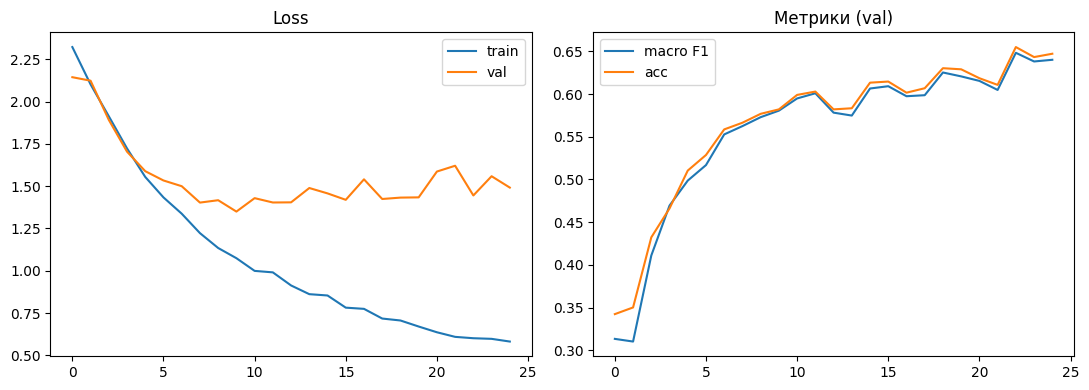

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[1].plot(history["val_macro_f1"], label="macro F1")
ax[1].plot(history["val_acc"], label="acc")
ax[1].set_title("Метрики (val)")
ax[1].legend()
plt.tight_layout()
plt.show()


val:   0%|          | 0/96 [00:00<?, ?it/s]

Validation — accuracy: 0.6549479166666666
Validation — balanced accuracy: 0.6532449160035368
Validation — macro F1: 0.6482214992445441

              precision    recall  f1-score   support

        ANPA      0.588     0.667     0.625        30
        COTO      0.650     0.520     0.578        25
        EPFU      0.520     0.433     0.473        30
        EUMA      0.903     0.933     0.918        30
        LABL      0.750     0.500     0.600        24
        LABO      0.519     0.467     0.491        30
        LACI      0.688     0.367     0.478        30
        LAIN      0.781     0.833     0.806        30
        LANO      0.731     0.633     0.679        30
        LASE      0.767     0.767     0.767        30
        MYCA      0.485     0.533     0.508        30
        MYCI      0.682     0.500     0.577        30
        MYEV      0.815     0.733     0.772        30
        MYGR      0.840     0.700     0.764        30
        MYLE      0.500     0.800     0.615        30

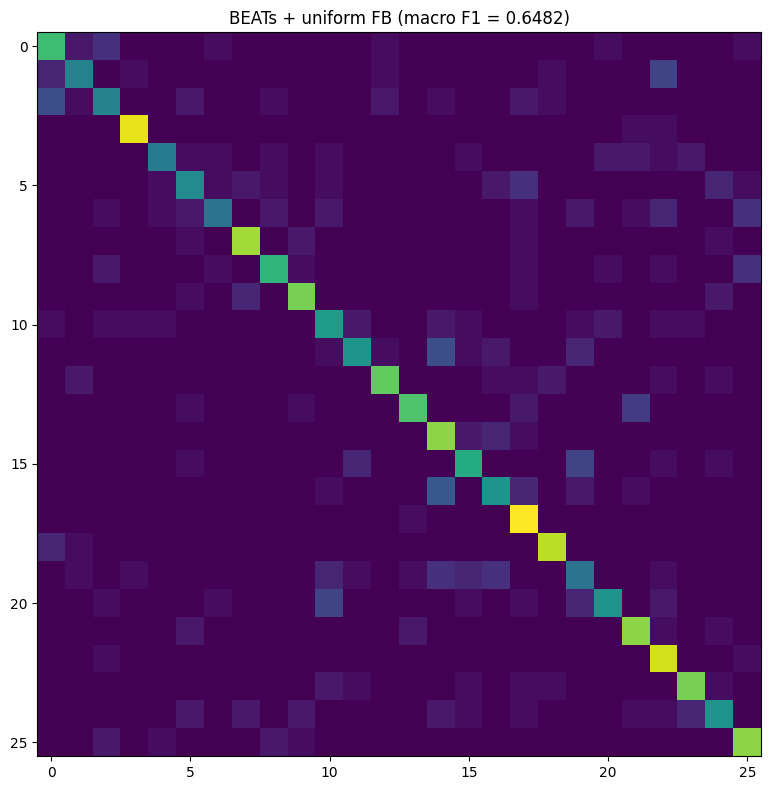

In [11]:
_ld_kw = {}
try:
    _ld_kw["weights_only"] = False
    ckpt = torch.load(BEST_CKPT, map_location=device, **_ld_kw)
except TypeError:
    ckpt = torch.load(BEST_CKPT, map_location=device)
classifier.load_state_dict(ckpt["classifier_state"])

_, acc, bal, macro_f1, y_true, y_pred = evaluate(classifier, val_loader)
labels_order = list(label2id.keys())
print("Validation — accuracy:", acc)
print("Validation — balanced accuracy:", bal)
print("Validation — macro F1:", macro_f1)
print()
print(classification_report(y_true, y_pred, target_names=labels_order, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cm)
ax.set_title(f"BEATs + uniform FB (macro F1 = {macro_f1:.4f})")
plt.tight_layout()
plt.show()
